# Step 1: Create Dataset using SAM2

This notebook implements the first stage of the pipeline:
1. **Extract frames** from an input video using OpenCV
2. **Load SAM2** (Segment Anything Model 2) to generate high-quality segmentation masks
3. **Interactive annotation** – click on the object in the first frame
4. **Propagate masks** across all frames using SAM2's video predictor
5. **Save** raw images and binary masks as the training dataset

> **Note:** SAM2 requires the `sam2` package and model checkpoints. See [SAM2 GitHub](https://github.com/facebookresearch/sam2) for setup.

## 1.1 Install & Import Dependencies

In [2]:
# Uncomment to install dependencies if needed
# !pip install opencv-python torch torchvision numpy matplotlib Pillow
# !pip install sam2  # or clone the SAM2 repo and install locally

In [3]:
import os
import sys
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.6.0
CUDA available: False
MPS available: True


## 1.2 Configuration

Set your paths below. You need:
- A **video file** to extract frames from
- The **SAM2 repo path** and **checkpoint file**
- An **output directory** to save the dataset

In [4]:
# ============================================================
# CONFIGURATION – Update these paths for your environment
# ============================================================

# Root project folder
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Input video path
VIDEO_PATH = os.path.join(PROJECT_ROOT, "Media", "video 1.mov")

# SAM2 setup
SAM2_REPO_PATH = os.path.join(PROJECT_ROOT, "sam2_repo")
SAM2_CHECKPOINT = os.path.join(SAM2_REPO_PATH, "checkpoints", "sam2.1_hiera_large.pt")
SAM2_MODEL_CFG = "configs/sam2.1/sam2.1_hiera_l.yaml"

# SAM2_MODEL_CFG = "/Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/sam2_repo/configs/sam2.1_hiera_l.yaml"

# Output dataset directories
DATASET_DIR = os.path.join(PROJECT_ROOT, "pipeline", "dataset")
RAW_IMAGES_DIR = os.path.join(DATASET_DIR, "raw_images")
BINARY_MASKS_DIR = os.path.join(DATASET_DIR, "binary_masks")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames_for_sam2")  # JPEG frames for SAM2 video predictor

# Create output directories
os.makedirs(RAW_IMAGES_DIR, exist_ok=True)
os.makedirs(BINARY_MASKS_DIR, exist_ok=True)
os.makedirs(FRAMES_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Video path: {VIDEO_PATH}")
print(f"Dataset will be saved to: {DATASET_DIR}")

Project root: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main
Video path: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/Media/video 1.mov
Dataset will be saved to: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/dataset


## 1.3 Extract Frames from Video

We read the input video frame-by-frame with OpenCV and save each frame as a JPEG image.

In [5]:
def extract_frames(video_path, output_dir, frame_skip=1):
    """
    Extract frames from a video file and save as JPEG images.
    
    Args:
        video_path: Path to input video file
        output_dir: Directory to save extracted frames
        frame_skip: Save every Nth frame (1 = every frame, 3 = every 3rd frame)
    
    Returns:
        Number of frames saved
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video info: {total_frames} frames, {fps:.1f} FPS, {width}x{height}")
    
    saved_count = 0
    frame_idx = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_idx % frame_skip == 0:
            # Save frame as JPEG (numbered sequentially)
            filename = f"{saved_count:04d}.jpg"
            cv2.imwrite(os.path.join(output_dir, filename), frame)
            saved_count += 1
        
        frame_idx += 1
    
    cap.release()
    print(f"Extracted {saved_count} frames (from {total_frames} total, skip={frame_skip})")
    return saved_count

In [6]:
# Extract frames – save every frame (set frame_skip=3 to subsample)
num_frames = extract_frames(VIDEO_PATH, RAW_IMAGES_DIR, frame_skip=3)

# Also save frames to the SAM2 frames directory (SAM2 video predictor reads from a folder)
_ = extract_frames(VIDEO_PATH, FRAMES_DIR, frame_skip=3)

Video info: 4680 frames, 59.8 FPS, 2880x1592
Extracted 1560 frames (from 4680 total, skip=3)
Video info: 4680 frames, 59.8 FPS, 2880x1592
Extracted 1560 frames (from 4680 total, skip=3)


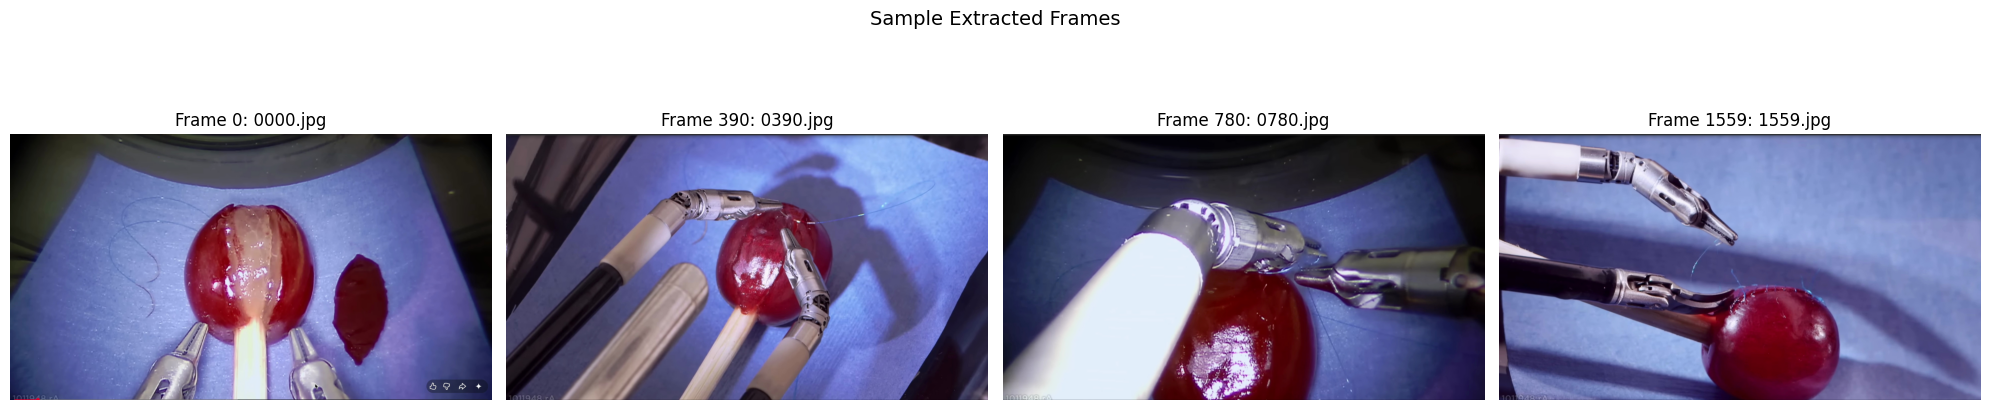

Total frames extracted: 1560


In [7]:
# Visualize a few extracted frames
frame_names = sorted([f for f in os.listdir(RAW_IMAGES_DIR) if f.endswith('.jpg')])
sample_indices = [0, len(frame_names)//4, len(frame_names)//2, len(frame_names)-1]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, idx in enumerate(sample_indices):
    img = Image.open(os.path.join(RAW_IMAGES_DIR, frame_names[idx]))
    axes[i].imshow(img)
    axes[i].set_title(f"Frame {idx}: {frame_names[idx]}")
    axes[i].axis('off')
plt.suptitle("Sample Extracted Frames", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total frames extracted: {len(frame_names)}")

## 1.4 Load SAM2 Model

We load the SAM2 video predictor, which can track and segment objects across video frames after receiving an initial prompt (point click or bounding box) on the first frame.

> **Prerequisites:** You need to have the SAM2 repository cloned into `sam2_repo/` and the model checkpoint downloaded.

In [8]:
# Add SAM2 repo to path
sys.path.insert(0, SAM2_REPO_PATH)

from sam2.build_sam import build_sam2_video_predictor

# Select device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Enable optimizations for CUDA
if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print("Note: MPS support is preliminary. Results may differ slightly from CUDA.")

# Build predictor
predictor = build_sam2_video_predictor(SAM2_MODEL_CFG, SAM2_CHECKPOINT, device=device)
print("SAM2 model loaded successfully!")

# Replace the device line with:
device = torch.device("cpu")

# Then rebuild the predictor
predictor = build_sam2_video_predictor(SAM2_MODEL_CFG, SAM2_CHECKPOINT, device=device)


Using device: mps
Note: MPS support is preliminary. Results may differ slightly from CUDA.
SAM2 model loaded successfully!


## 1.5 Interactive Annotation – Click on Object

Display the first frame and click on the object you want to segment. The click provides SAM2 with a **point prompt** to identify the target object.

- **Left click** = positive point (this IS the object)
- **Right click** = negative point (this is NOT the object)

In [9]:
%matplotlib inline

In [10]:
# Helper visualization functions (from original project)

def show_mask(mask, ax, obj_id=None, random_color=False):
    """Overlay a colored mask on the given axes."""
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    """Plot positive (green) and negative (red) click points."""
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)

In [11]:
def get_clicks_from_user(image, max_clicks=5, use_negative_clicks=True):
    """
    Display an image and let the user click to select points.
    
    Args:
        image: PIL Image to display
        max_clicks: Maximum number of clicks before closing
        use_negative_clicks: If True, right-click = negative point
    
    Returns:
        points: np.ndarray of shape (N, 2) – click coordinates
        labels: np.ndarray of shape (N,) – 1=positive, 0=negative
    """
    click_coords = []
    click_labels = []

    def onclick(event):
        if event.xdata is not None and event.ydata is not None:
            x, y = int(event.xdata), int(event.ydata)
            if use_negative_clicks and event.button == 3:
                print(f"Negative click at ({x}, {y})")
                label = 0
                color = 'red'
            else:
                print(f"Positive click at ({x}, {y})")
                label = 1
                color = 'green'

            click_coords.append([x, y])
            click_labels.append(label)
            ax.scatter(x, y, color=color, marker='*', s=200, edgecolor='white')
            fig.canvas.draw()

            if len(click_coords) >= max_clicks:
                plt.close()

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image)
    ax.set_title("Click on the object to segment (left=positive, right=negative)")
    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    plt.show()
    fig.canvas.mpl_disconnect(cid)

    return np.array(click_coords, dtype=np.float32), np.array(click_labels, dtype=np.int32)

Found 1560 frames


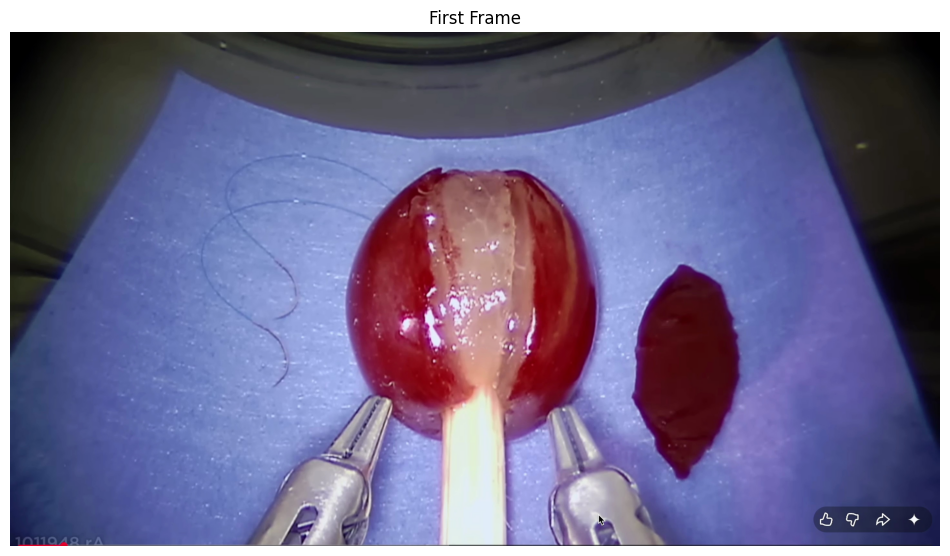

In [12]:
# Load frame names from the frames directory
frame_names = sorted([
    p for p in os.listdir(FRAMES_DIR)
    if os.path.splitext(p)[-1].lower() in [".jpg", ".jpeg"]
])
print(f"Found {len(frame_names)} frames")

# Display the first frame
first_frame = Image.open(os.path.join(FRAMES_DIR, frame_names[0]))
plt.figure(figsize=(12, 8))
plt.imshow(first_frame)
plt.title("First Frame")
plt.axis('off')
plt.show()

In [13]:
# # Interactive: click on the object to segment
# # The window will close after max_clicks or when you close it manually
# points, labels = get_clicks_from_user(first_frame, max_clicks=5, use_negative_clicks=True)

# print(f"\nSelected {len(points)} points:")
# for i, (pt, lbl) in enumerate(zip(points, labels)):
#     print(f"  Point {i}: ({pt[0]:.0f}, {pt[1]:.0f}) - {'Positive' if lbl == 1 else 'Negative'}")

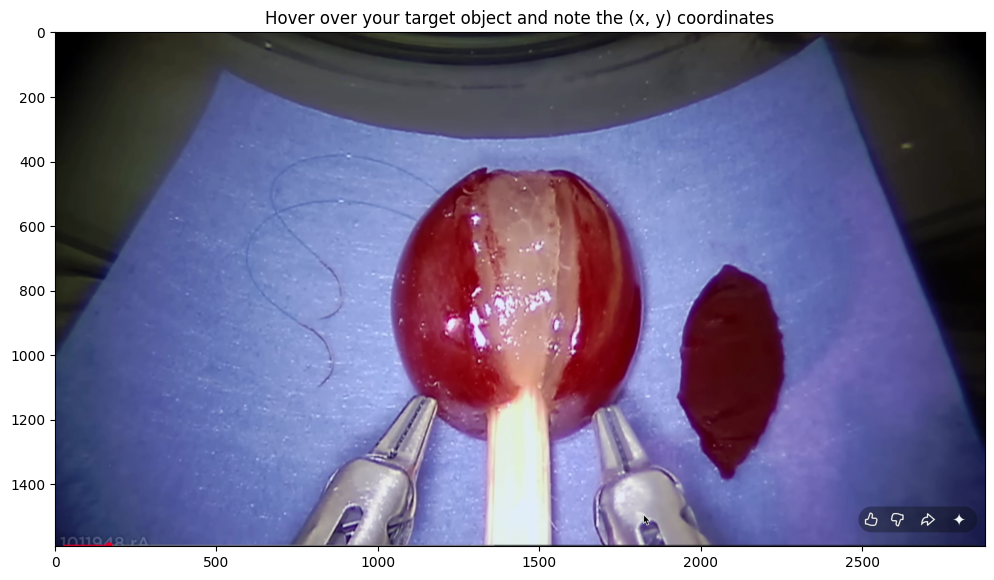

In [14]:
# Display first frame to find object coordinates
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(first_frame)
ax.set_title("Hover over your target object and note the (x, y) coordinates")
ax.axis('on')  # keep axes on so you can read coordinates
plt.show()


In [15]:
import numpy as np

# Replace these coordinates with where YOUR object is in the first frame
# Put your cursor on the object in the image above and note the x, y values

points = np.array([
    [1000, 1400],
    [1800, 1400]
], dtype=np.float32)

labels = np.array([1,1], dtype=np.int32)  # 1 = positive point ("this is the object")

print(f"\nSelected {len(points)} points:")
for i, (pt, lbl) in enumerate(zip(points, labels)):
    print(f"  Point {i}: ({pt[0]:.0f}, {pt[1]:.0f}) - {'Positive' if lbl == 1 else 'Negative'}")


# import numpy as np

# # Object 1
# points_obj1 = np.array([[1000, 1400]], dtype=np.float32)
# labels_obj1 = np.array([1], dtype=np.int32)

# # Object 2
# points_obj2 = np.array([[1800, 1400]], dtype=np.float32)
# labels_obj2 = np.array([1], dtype=np.int32)

# print(f"Object 1: point ({points_obj1[0][0]:.0f}, {points_obj1[0][1]:.0f})")
# print(f"Object 2: point ({points_obj2[0][0]:.0f}, {points_obj2[0][1]:.0f})")



Selected 2 points:
  Point 0: (1000, 1400) - Positive
  Point 1: (1800, 1400) - Positive


## 1.6 Initialize SAM2 & Add Prompt

We initialize SAM2's video predictor with our frames directory and add the clicked point(s) as prompts on the first frame.

frame loading (JPEG): 100%|██████████| 1560/1560 [01:56<00:00, 13.44it/s]
/opt/homebrew/lib/python3.10/site-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/opt/homebrew/lib/python3.10/site-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


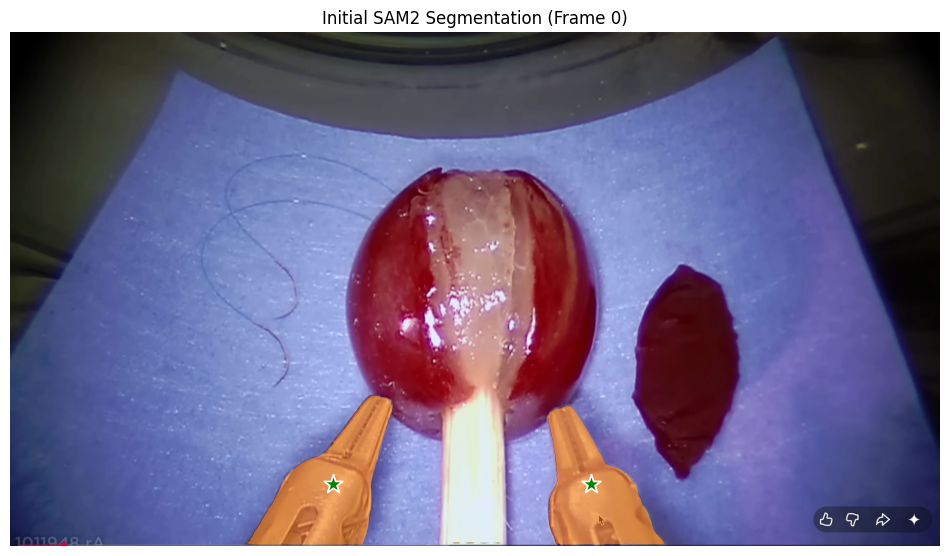

Initial prompt added successfully!


In [16]:
# Initialize SAM2 inference state with our frames
# inference_state = predictor.init_state(video_path=FRAMES_DIR)
inference_state = predictor.init_state(
    video_path=FRAMES_DIR,
    offload_video_to_cpu=True,
    offload_state_to_cpu=True,
)

predictor.reset_state(inference_state)

# Add clicked points as prompts on the first frame
ann_frame_idx = 0
ann_obj_id = 1  # Object ID (use different IDs for multiple objects)

_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# Visualize the initial segmentation result
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(first_frame)
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), ax, obj_id=ann_obj_id)
show_points(points, labels, ax)
ax.set_title("Initial SAM2 Segmentation (Frame 0)")
ax.axis('off')
plt.show()

print("Initial prompt added successfully!")

In [17]:
# # inference_state = predictor.init_state(video_path=FRAMES_DIR)
# inference_state = predictor.init_state(
#     video_path=FRAMES_DIR,
#     offload_video_to_cpu=True,
#     offload_state_to_cpu=True,
# )
# predictor.reset_state(inference_state)

# ann_frame_idx = 0

# # Add Object 1
# _, out_obj_ids1, out_mask_logits1 = predictor.add_new_points_or_box(
#     inference_state=inference_state,
#     frame_idx=ann_frame_idx,
#     obj_id=1,
#     points=points_obj1,
#     labels=labels_obj1,
# )

# # Add Object 2
# _, out_obj_ids2, out_mask_logits2 = predictor.add_new_points_or_box(
#     inference_state=inference_state,
#     frame_idx=ann_frame_idx,
#     obj_id=2,
#     points=points_obj2,
#     labels=labels_obj2,
# )

# # Visualize both masks
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.imshow(first_frame)
# show_mask((out_mask_logits1[0] > 0.0).cpu().numpy(), ax, obj_id=1)
# show_mask((out_mask_logits2[0] > 0.0).cpu().numpy(), ax, obj_id=2)
# show_points(points_obj1, labels_obj1, ax)
# show_points(points_obj2, labels_obj2, ax)
# ax.set_title("Initial SAM2 Segmentation (Frame 0) - 2 Objects")
# ax.axis('off')
# plt.show()

# print("Both prompts added successfully!")


## 1.7 Propagate Masks Across All Frames

SAM2 will now track the object through every frame in the video and generate a binary mask for each frame. We save these masks to `binary_masks/` directory.

In [18]:
# Propagate segmentation across all frames
print("Propagating masks across all frames...")

video_segments = {}  # {frame_idx: {obj_id: mask}}

for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

print(f"Generated masks for {len(video_segments)} frames")

Propagating masks across all frames...


propagate in video:   0%|          | 0/1560 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 1560/1560 [3:04:38<00:00,  7.10s/it]  

Generated masks for 1560 frames


In [19]:
# Save binary masks as images
print("Saving binary masks...")

for frame_idx in sorted(video_segments.keys()):
    # Combine all object masks into a single binary mask
    masks = video_segments[frame_idx]
    combined_mask = None
    
    for obj_id, mask in masks.items():
        binary = mask.squeeze().astype(np.uint8) * 255
        if combined_mask is None:
            combined_mask = binary
        else:
            combined_mask = np.bitwise_or(combined_mask, binary)
    
    # Save mask with the same filename as the corresponding frame
    mask_filename = frame_names[frame_idx]
    mask_path = os.path.join(BINARY_MASKS_DIR, mask_filename)
    cv2.imwrite(mask_path, combined_mask)

print(f"Saved {len(video_segments)} binary masks to: {BINARY_MASKS_DIR}")

Saving binary masks...
Saved 1560 binary masks to: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/dataset/binary_masks


## 1.8 Visualize Dataset Samples

Let's verify the quality of our generated dataset by viewing some image-mask pairs side by side.

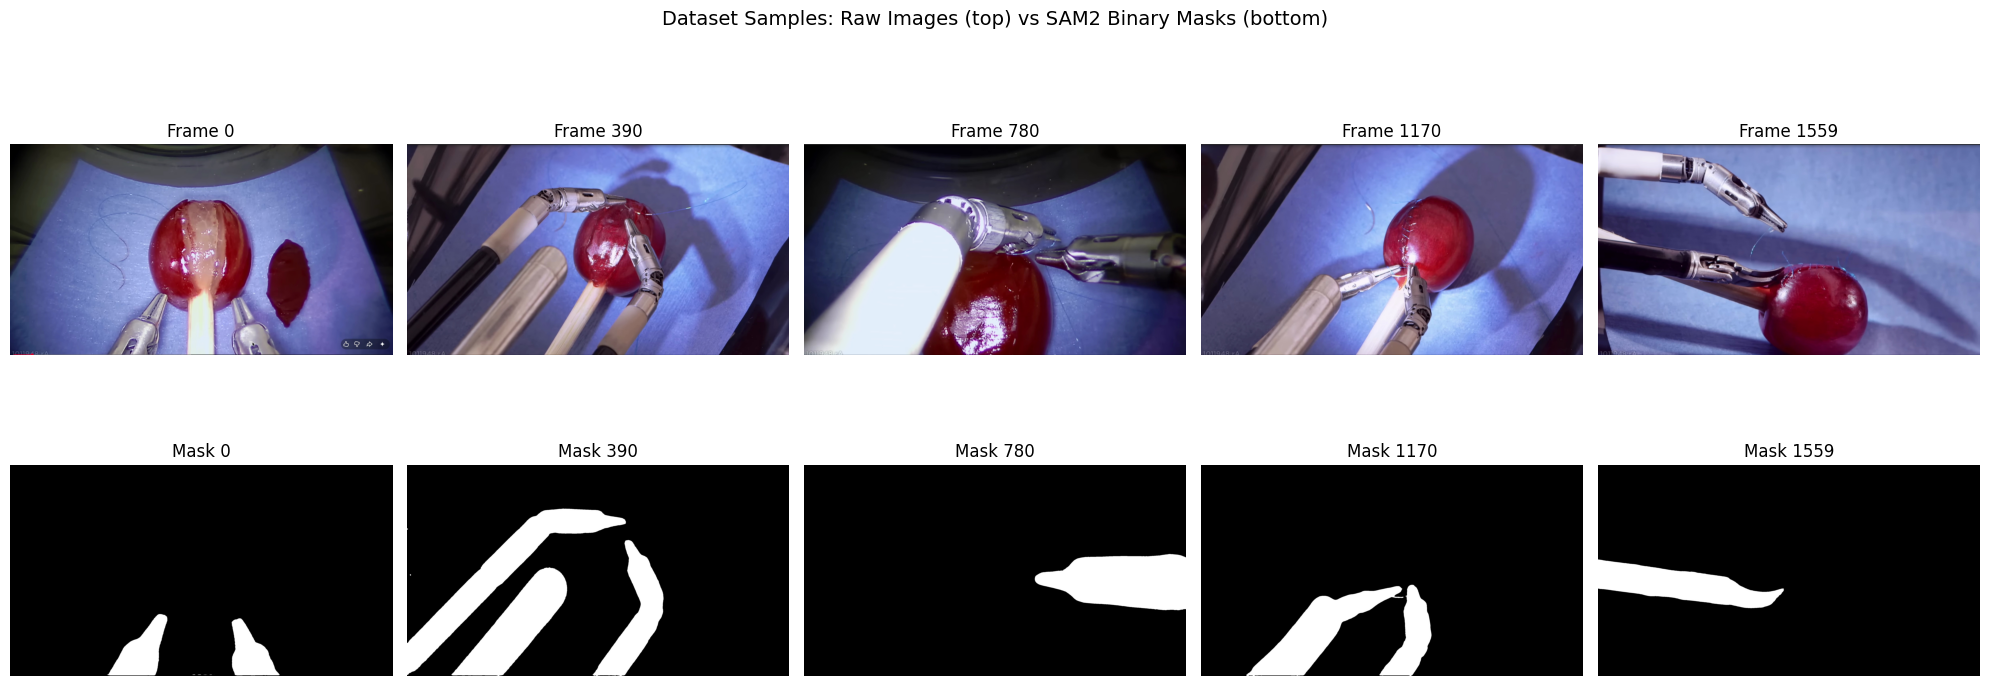


Dataset Summary:
  Raw images: 1560 (in /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/dataset/raw_images)
  Binary masks: 1560 (in /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/dataset/binary_masks)

Dataset is ready for UNet training! Proceed to Notebook 02.


In [20]:
# Visualize sample image-mask pairs
sample_indices = [0, len(frame_names)//4, len(frame_names)//2, 3*len(frame_names)//4, len(frame_names)-1]

fig, axes = plt.subplots(2, len(sample_indices), figsize=(20, 8))

for i, idx in enumerate(sample_indices):
    fname = frame_names[idx]
    
    # Raw image
    img = Image.open(os.path.join(RAW_IMAGES_DIR, fname))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Frame {idx}")
    axes[0, i].axis('off')
    
    # Binary mask
    mask_path = os.path.join(BINARY_MASKS_DIR, fname)
    if os.path.exists(mask_path):
        mask = Image.open(mask_path)
        axes[1, i].imshow(mask, cmap='gray')
    else:
        axes[1, i].text(0.5, 0.5, 'No mask', ha='center', va='center')
    axes[1, i].set_title(f"Mask {idx}")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Raw Images", fontsize=12)
axes[1, 0].set_ylabel("Binary Masks", fontsize=12)
plt.suptitle("Dataset Samples: Raw Images (top) vs SAM2 Binary Masks (bottom)", fontsize=14)
plt.tight_layout()
plt.show()

# Print dataset summary
num_images = len(os.listdir(RAW_IMAGES_DIR))
num_masks = len(os.listdir(BINARY_MASKS_DIR))
print(f"\nDataset Summary:")
print(f"  Raw images: {num_images} (in {RAW_IMAGES_DIR})")
print(f"  Binary masks: {num_masks} (in {BINARY_MASKS_DIR})")
print(f"\nDataset is ready for UNet training! Proceed to Notebook 02.")